In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [49]:
df.shape

(32581, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [51]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

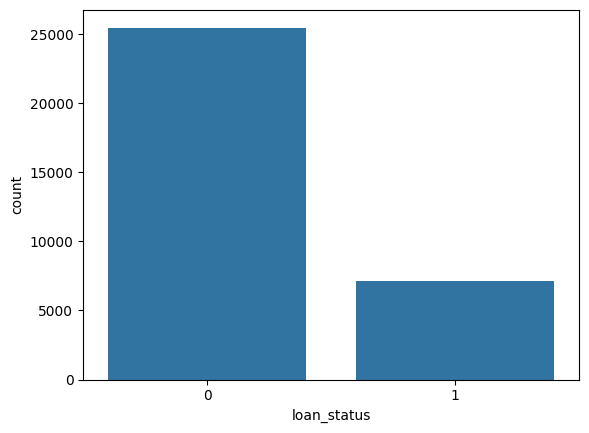

In [52]:
df['loan_status'].value_counts()
sns.countplot(data=df, x='loan_status')

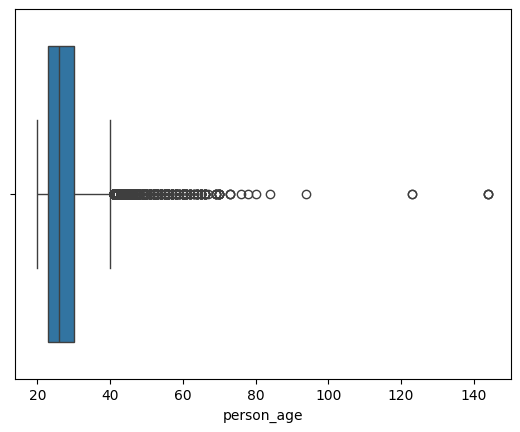

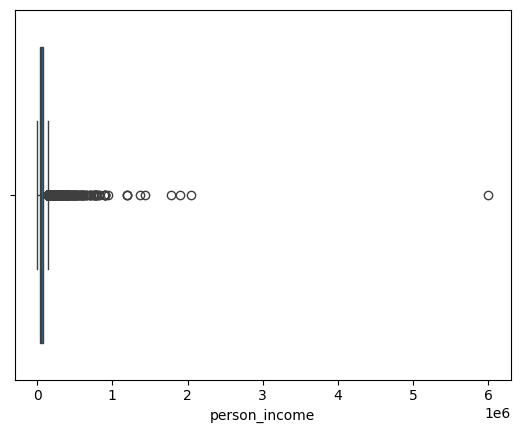

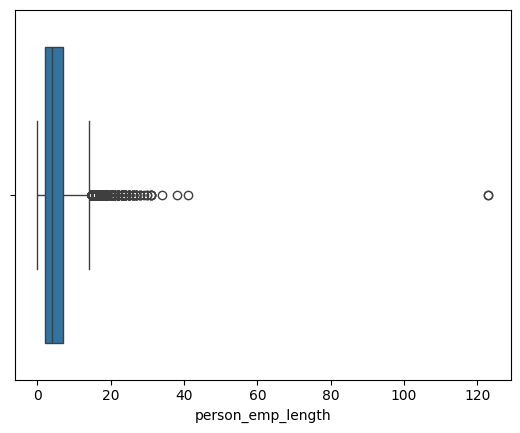

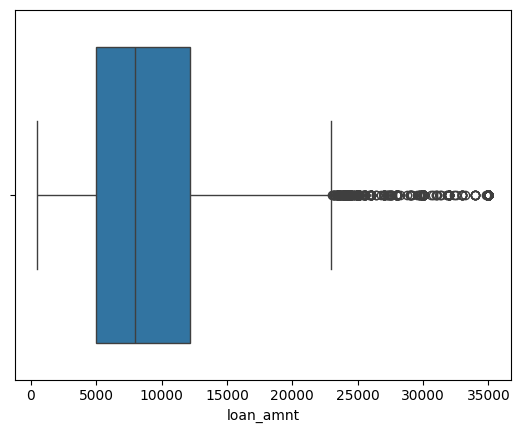

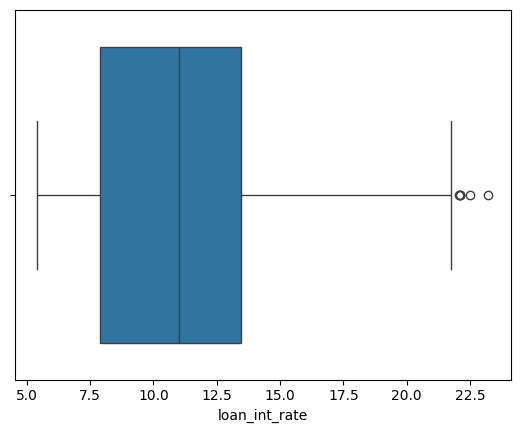

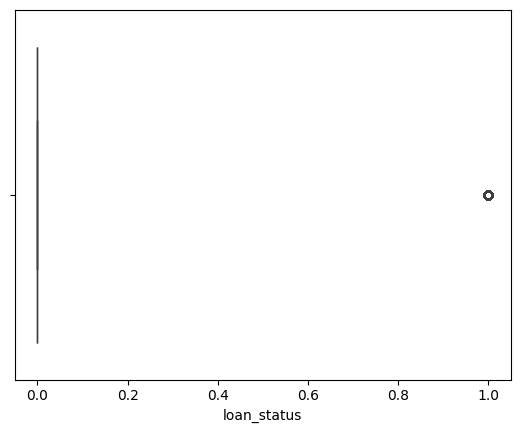

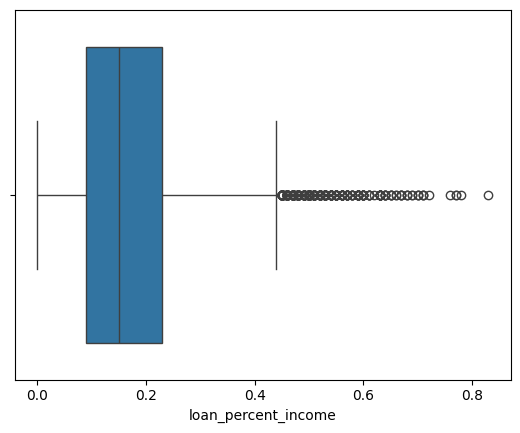

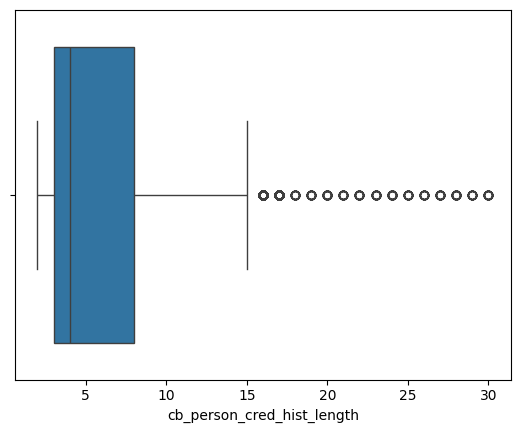

In [53]:
num_col = df.select_dtypes(include=np.number).columns

for i in num_col:
    sns.boxplot(x=df[i])
    plt.show()

In [54]:
(df['person_age'] > 100).sum()

np.int64(5)

In [55]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [56]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

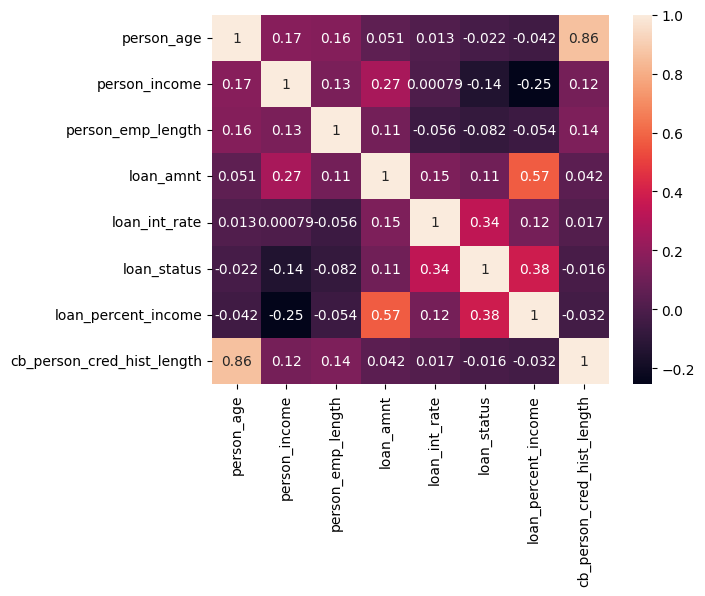

In [57]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [58]:
df_copy = df.copy()

In [59]:
print(f'Original row: {df_copy.shape[0]}')

df_copy.drop_duplicates(inplace=True)
print(f'After remove dup row: {df_copy.shape[0]}')

Original row: 32581
After remove dup row: 32416


In [60]:
df_copy = df_copy[(df_copy['person_age'] <= 100) & (df_copy['person_age'] > 18)]

In [61]:
df_copy = df_copy[(df_copy['person_emp_length'] <= df_copy['person_age']) & (df_copy['person_emp_length'] <= 60)]


In [62]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [63]:
(df_copy['loan_amnt'] < 0).sum()

np.int64(0)

# ----------------------------------------

In [64]:
X = df_copy.drop(columns=['loan_status'])
y = df_copy['loan_status']

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
numericl_col = ['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_col = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

In [67]:
neg, pos = np.bincount(y_train)
scale_weight = neg / pos
scale_weight

np.float64(3.6092122098336685)

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Numerical Col 
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericl_col),
        
        # Category Col 
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_col)
    ]
)


preprocessor_xg = ColumnTransformer(
    transformers=[
        # Numerical Col 
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            # ('scaler', StandardScaler())
        ]), numericl_col),
        
        # Category Col 
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_col)
    ]
)

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve
def evaluateModel(model_name, model, X_test, y_test, thresold=None):
    # y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:,1]
    
    if thresold:
        y_pred = (y_pred_prob >= thresold).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)
    
    print(f'accuracy: {accuracy:.2f}')
    print(f'precision: {precision:.2f}')
    print(f'recall: {recall:.2f}')
    print(f'f1: {f1:.2f}')
    print(f'best_thresold: {thresold}')
    print()
    print(model_name)
    print(classification_rep)
    
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{model_name} heatmap')
    plt.xlabel('Actual value')
    plt.ylabel('Predicted value')
    plt.show()
    
    precisions, recalls, thresold = precision_recall_curve(y_test, y_pred_prob)
    plt.plot(recalls, precisions)
    plt.title(f'{model_name} precision_recall_curve')
    plt.xlabel('recall')
    plt.ylabel('precision')
    plt.show()

In [70]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Logistic

In [71]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
# lr_pipeline

# XG Boost

In [72]:
from xgboost import XGBClassifier
xg_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=42,
        learning_rate=0.1,
        n_estimators=300,
        max_depth=5,
    ))
])
# xg_pipeline

In [73]:
# for name, model in [('Logistic Regression', lr_pipeline), ('XGBoost', xg_pipeline)]:
#     res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
#     print(name)
#     print(f'ROC-AUC: {res['test_roc_auc'].mean()}')
#     print(f'Accuracy: {res['test_accuracy'].mean()}')
#     print(f'Precision: {res['test_precision'].mean()}')
#     print(f'Recall: {res['test_recall'].mean()}')
#     print(f'F1: {res['test_f1'].mean()}')
#     print()


In [74]:
base_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
base_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [75]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_weight, random_state=42))
])
xg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

accuracy: 0.81
precision: 0.54
recall: 0.77
f1: 0.63
best_thresold: None

LogisticRegression
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4969
           1       0.54      0.77      0.63      1336

    accuracy                           0.81      6305
   macro avg       0.73      0.79      0.75      6305
weighted avg       0.85      0.81      0.82      6305



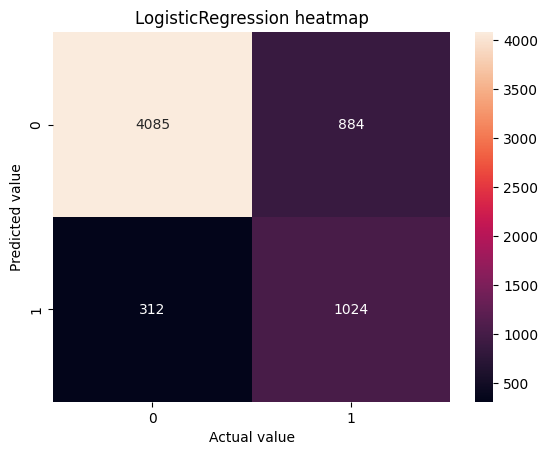

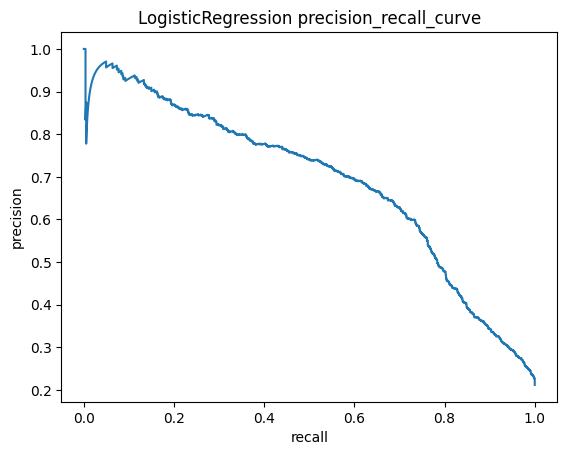

In [76]:
evaluateModel('LogisticRegression', base_model, X_test, y_test)

accuracy: 0.91
precision: 0.80
recall: 0.77
f1: 0.79
best_thresold: None

XGBoost
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4969
           1       0.80      0.77      0.79      1336

    accuracy                           0.91      6305
   macro avg       0.87      0.86      0.87      6305
weighted avg       0.91      0.91      0.91      6305



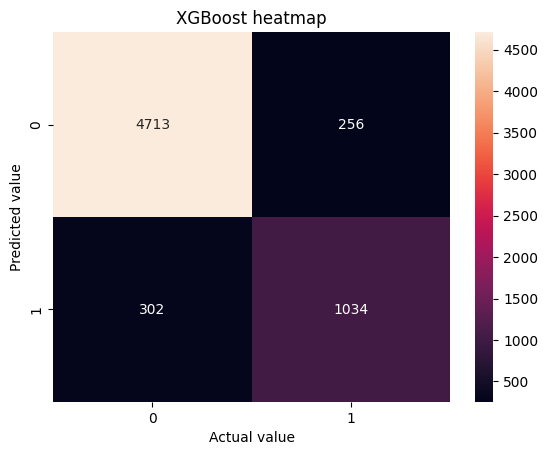

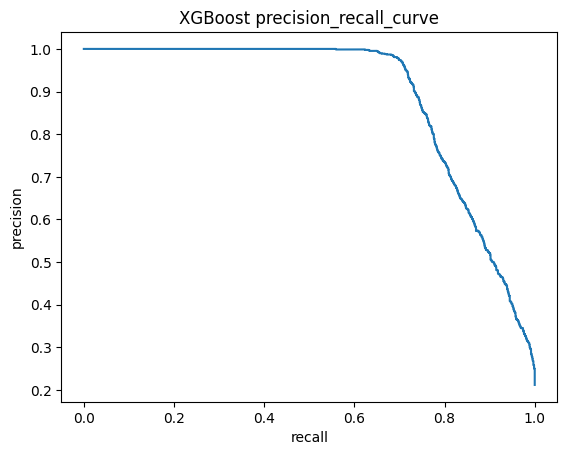

In [77]:
evaluateModel('XGBoost', xg_model, X_test, y_test, None)

# Model hyperparameters tuning

In [78]:
from sklearn.model_selection import RandomizedSearchCV
pram_grid = {
    'classifier__n_estimators': np.random.randint(150, 600, 5),
    'classifier__max_depth': np.random.randint(3, 10, 5),
    'classifier__learning_rate': np.random.uniform(0.01, 0.5, 5),
    'classifier__subsample': np.random.uniform(0.4, 0.6, 5),
    'classifier__colsample_bytree': np.random.uniform(0.4, 0.6, 5),
    'classifier__gamma': np.random.uniform(0, 5, 5),
    'classifier__min_child_weight': np.random.randint(1, 10, 5)
}

In [89]:
random_search = RandomizedSearchCV(
    estimator=xg_model,
    param_distributions=pram_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': array([0.5141..., 0.51108896]), 'classifier__gamma': array([1.2442..., 4.00658814]), 'classifier__learning_rate': array([0.3906..., 0.28791555]), 'classifier__max_depth': array([9, 8, ..., dtype=int32), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the split

In [90]:
random_search.best_params_

{'classifier__subsample': np.float64(0.4873730250097402),
 'classifier__n_estimators': np.int32(445),
 'classifier__min_child_weight': np.int32(5),
 'classifier__max_depth': np.int32(8),
 'classifier__learning_rate': np.float64(0.07041053570528956),
 'classifier__gamma': np.float64(4.006588138833351),
 'classifier__colsample_bytree': np.float64(0.5110889596335768)}

In [ ]:
# {'classifier__subsample': np.float64(0.4873730250097402),
#  'classifier__n_estimators': np.int32(445),
#  'classifier__min_child_weight': np.int32(5),
#  'classifier__max_depth': np.int32(8),
#  'classifier__learning_rate': np.float64(0.07041053570528956),
#  'classifier__gamma': np.float64(4.006588138833351),
#  'classifier__colsample_bytree': np.float64(0.5110889596335768)}

In [91]:
print(f'XGBoost score: {random_search.best_score_:.2f}')

XGBoost score: 0.90


accuracy: 0.91
precision: 0.80
recall: 0.79
f1: 0.79
best_thresold: None

XGBoost RandomizedSearchCV
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4969
           1       0.80      0.79      0.79      1336

    accuracy                           0.91      6305
   macro avg       0.87      0.87      0.87      6305
weighted avg       0.91      0.91      0.91      6305



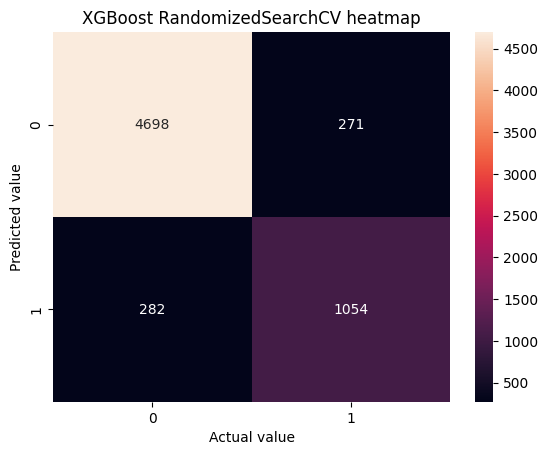

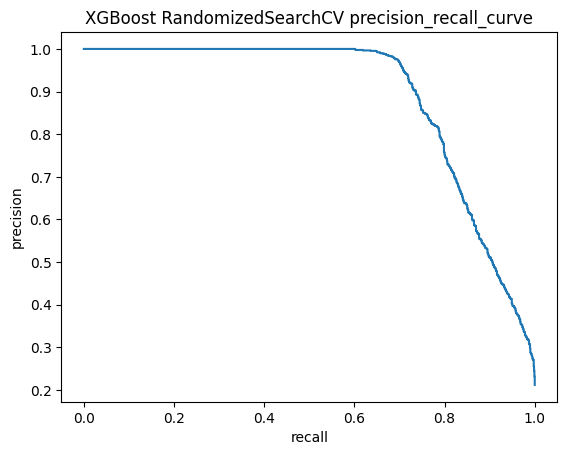

In [92]:
evaluateModel('XGBoost RandomizedSearchCV', random_search.best_estimator_, X_test, y_test)

# thresold

accuracy: 0.93
precision: 0.94
recall: 0.72
f1: 0.81
best_thresold: 0.6955174803733826

XGBoost best_thresold
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4969
           1       0.94      0.72      0.81      1336

    accuracy                           0.93      6305
   macro avg       0.93      0.85      0.89      6305
weighted avg       0.93      0.93      0.93      6305



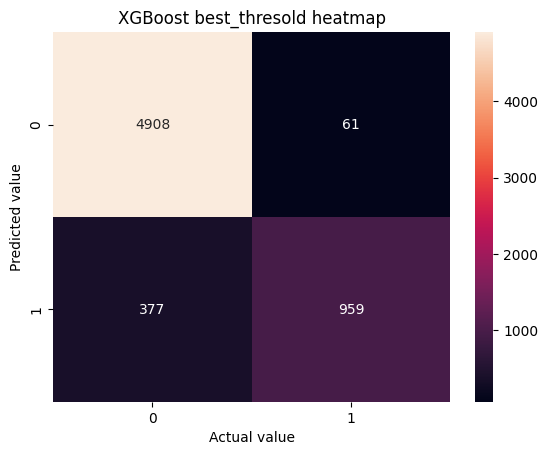

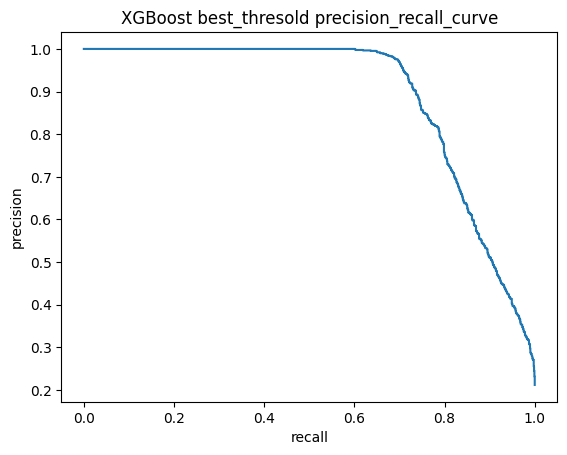

In [93]:
precisions, recalls, thresold = precision_recall_curve(y_test, random_search.best_estimator_.predict_proba(X_test)[:,1])

f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_f1 = np.argmax(f1[:-1])
# print(best_f1)
best_thresold = thresold[best_f1]

evaluateModel('XGBoost best_thresold', random_search.best_estimator_, X_test, y_test, best_thresold)

# Calibration

In [84]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibration_model = CalibratedClassifierCV(
    estimator=random_search.best_estimator_, 
    method='sigmoid', 
    cv=5
)
calibration_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [85]:
unclibrated = random_search.best_estimator_.predict_proba(X_test)[:,1]
clibrated = calibration_model.predict_proba(X_test)[:,1]

In [86]:
actual_uncal, pred_uncal = calibration_curve(y_test, unclibrated, n_bins=10)
actual_clib, pred_clib = calibration_curve(y_test, clibrated, n_bins=10)

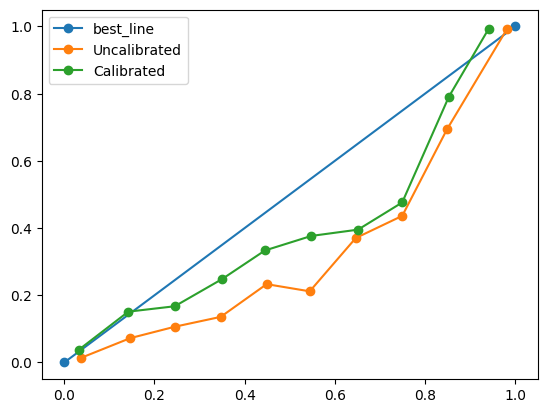

In [87]:
plt.plot([0,1], [0,1], marker='o', label='best_line')
plt.plot(pred_uncal, actual_uncal, marker='o', label='Uncalibrated')
plt.plot(pred_clib, actual_clib, marker='o', label='Calibrated')
plt.legend()

In [94]:
import joblib

joblib.dump(calibration_model, 'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [95]:
joblib.dump(best_thresold, 'best_threshold.pkl')

['best_threshold.pkl']